In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn. cluster import KMeans,DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
X,y_true = make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)
df = pd.DataFrame(X,columns=["Feature_1","Feature_2"])
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [3]:
scaler = StandardScaler()
x_scaler = scaler.fit_transform(df)
x_scaler

array([[-9.69818350e-01, -1.33993820e+00],
       [ 9.63343617e-01,  8.22475346e-02],
       [ 1.57864695e+00,  1.26351772e-02],
       [-2.46735247e-01,  1.03557927e+00],
       [ 1.45416962e+00,  4.95852224e-02],
       [ 1.40747082e+00,  8.22344111e-03],
       [-7.92177264e-01, -1.28388698e+00],
       [ 1.33697413e+00,  8.26220693e-02],
       [ 1.16849128e+00,  7.41152400e-02],
       [-1.19320161e+00, -1.27260956e+00],
       [ 1.22150712e+00, -1.25922376e-02],
       [-5.14797137e-02,  1.09492794e+00],
       [ 7.12157877e-02,  9.90472440e-01],
       [-1.25480095e-01,  1.27553591e+00],
       [ 1.33940654e+00,  2.78868839e-01],
       [ 1.43619041e+00, -7.51130357e-02],
       [-2.06430378e-01,  1.26334617e+00],
       [-1.25589470e+00, -1.23971291e+00],
       [-1.10416740e+00, -1.17664933e+00],
       [-3.36666506e-01,  1.06025816e+00],
       [ 1.12682035e+00,  1.39235617e-01],
       [-1.71064404e-01,  9.89772412e-01],
       [ 1.37551647e+00,  1.15995990e-01],
       [-9.

In [4]:
inertia = []
K_range = range(1,11)

In [5]:
for k in K_range:
    k_means = KMeans(n_clusters=k,random_state=42)
    k_means.fit(x_scaler)
    inertia.append(k_means.inertia_)
inertia

[1000.0,
 297.8954141051723,
 11.57548472310498,
 9.752067977356841,
 8.257175272446284,
 6.9175773204168,
 6.334755391595291,
 5.704177177901429,
 5.060234133532076,
 4.762361898130396]

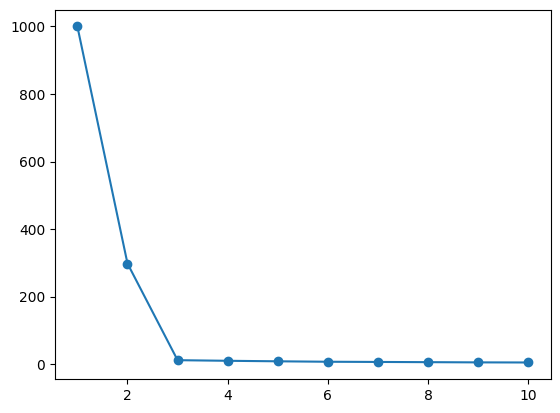

In [6]:
plt.plot(K_range,inertia,marker="o")
plt.show()

In [7]:
k_means_final = KMeans(n_clusters=3,random_state=42)

In [8]:
cluster_labels = k_means_final.fit_predict(x_scaler)
cluster_labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [9]:
df["cluster"] = cluster_labels
df.head()

,Feature_1,Feature_2,cluster
0,-6.190063,-7.302015,1
1,3.021747,1.940593,0
2,5.953761,1.488191,0
3,-2.744463,8.136177,2
4,5.360607,1.728324,0


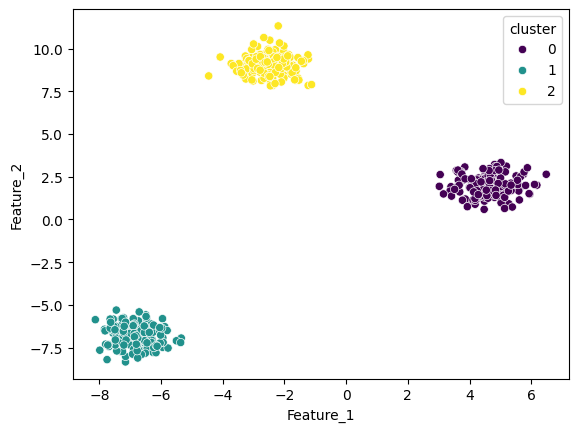

In [10]:
sns.scatterplot(x=df["Feature_1"],y=df["Feature_2"],hue=df["cluster"],palette="viridis")
plt.show()

In [11]:
from sklearn.datasets import make_moons
X,y_true = make_moons(n_samples=500,noise=0.05,random_state=42)
df = pd.DataFrame(X,columns=["Feature_1","Feature_2"])
df

,Feature_1,Feature_2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
...,...,...
495,0.239754,0.985462
496,0.072145,0.184834
497,0.590273,-0.365577
498,1.619465,-0.283658


In [12]:
X_scaler = scaler.fit_transform(df)

In [13]:
K_means = KMeans(n_clusters=2,random_state=42)
K_means_labels = K_means.fit_predict(X_scaler)

In [14]:
df["K_means_clusters"] = K_means_labels
df

,Feature_1,Feature_2,K_means_clusters
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0
...,...,...,...
495,0.239754,0.985462,0
496,0.072145,0.184834,0
497,0.590273,-0.365577,1
498,1.619465,-0.283658,1


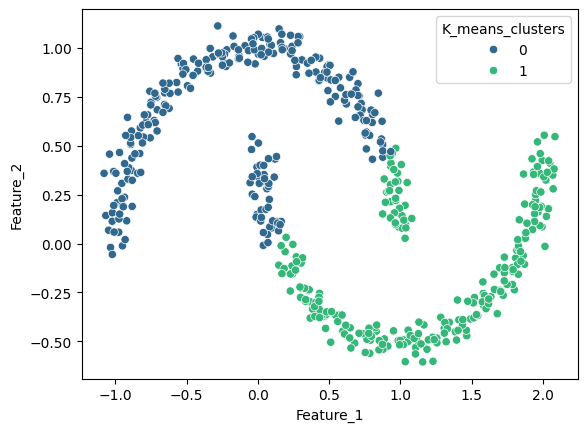

In [15]:
sns.scatterplot(x=df["Feature_1"],y=df["Feature_2"],hue=df["K_means_clusters"],palette="viridis")
plt.show()

In [16]:
dbscan = DBSCAN(eps=0.3,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaler)
df["dbscan_labels"] = dbscan_labels

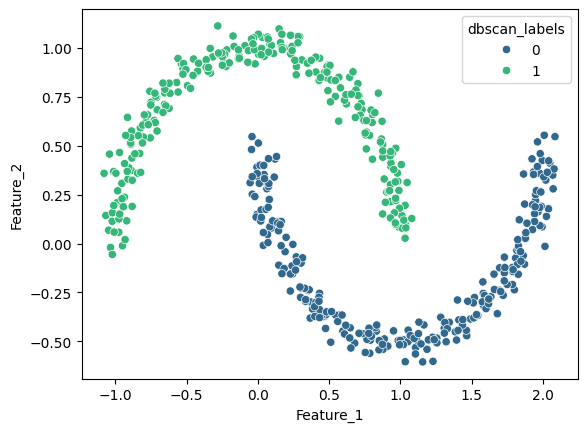

In [18]:
sns.scatterplot(x=df["Feature_1"],y=df["Feature_2"],hue=df["dbscan_labels"],palette="viridis")
plt.savefig("DBSCAN.png")
plt.show()